In [1]:
pip install pandas openpyxl sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [3]:
from sqlalchemy import create_engine
engine = create_engine("sqlite:///online_retail.db")
df.to_sql(
    "online_retail",
    engine,
    if_exists="replace",
    index=False
)
print("Table loaded successfully!")

Table loaded successfully!


In [4]:
query = "SELECT * FROM online_retail"
retail_df = pd.read_sql(query, engine)
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom


In [5]:
retail_df["InvoiceDate"] = pd.to_datetime(
    retail_df["InvoiceDate"]
)
retail_df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [6]:
retail_df["Year"] = retail_df["InvoiceDate"].dt.year
retail_df["Month"] = retail_df["InvoiceDate"].dt.month
retail_df["Day"] = retail_df["InvoiceDate"].dt.day
retail_df["DayName"] = retail_df["InvoiceDate"].dt.day_name()
retail_df["Hour"] = retail_df["InvoiceDate"].dt.hour

In [14]:
retail_df["Year"].value_counts().sort_index()

Year
2010     42481
2011    499428
Name: count, dtype: int64

In [7]:
retail_df["Month"].value_counts().sort_index()

Month
1     35147
2     27707
3     36748
4     29916
5     37030
6     36874
7     39518
8     35284
9     50226
10    60742
11    84711
12    68006
Name: count, dtype: int64

In [8]:
retail_df["DayName"].value_counts()

DayName
Thursday     103857
Tuesday      101808
Monday        95111
Wednesday     94565
Friday        82193
Sunday        64375
Name: count, dtype: int64

In [9]:
retail_df["Hour"].value_counts().sort_index()

Hour
6        41
7       383
8      8909
9     34332
10    49037
11    57674
12    78709
13    72259
14    67471
15    77519
16    54516
17    28509
18     7974
19     3705
20      871
Name: count, dtype: int64

In [10]:
print("Earliest Date:", retail_df["InvoiceDate"].min())
print("Latest Date:", retail_df["InvoiceDate"].max())

Earliest Date: 2010-12-01 08:26:00
Latest Date: 2011-12-09 12:50:00


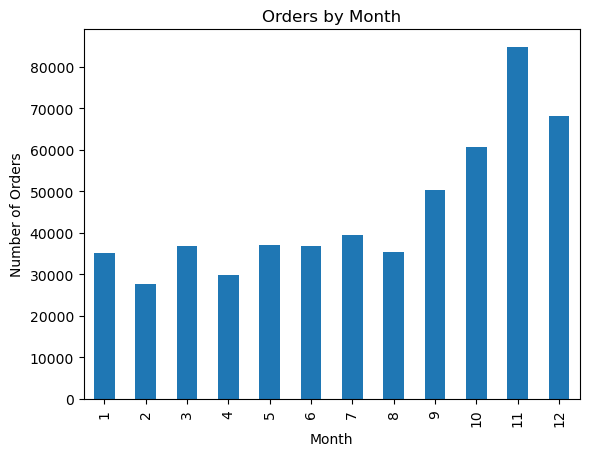

In [11]:
import matplotlib.pyplot as plt
monthly_orders = retail_df.groupby("Month").size()
monthly_orders.plot(kind="bar")
plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()